# 09 Continuous Probability Distributions

Chapter 08 studied discrete probability distributions. Now we move to **continuous random variables** such as time, height, temperature, and distance.

The main model in this chapter is the **Normal Distribution**.

## Learning Objectives

- Distinguish discrete and continuous random variables
- Understand probability as area under a density curve
- Understand PDF and CDF
- Understand the Normal Distribution
- Calculate interval and tail probabilities with SciPy
- Standardize observations with Z-scores
- Simulate continuous random variables

## 1. Continuous Random Variables

Let

$$X=\text{delivery time in minutes}$$

Values might be 42, 42.5, 42.53, and so on. Unlike a count, there is no finite list of all possible values.

Typical continuous variables include time, height, weight, temperature, distance, and rainfall.

## 2. Probability for Continuous Variables

For a continuous random variable,

$$P(X=x)=0$$

for any one exact value. This does **not** mean values near $x$ are impossible.

Probability is assigned to intervals, for example:

$$P(40\le X\le50)$$

The key idea is:

> **Probability = area under the density curve over an interval.**

## 3. Probability Density Function (PDF)

A continuous distribution is described by a density function $f(x)$.

$$P(a\le X\le b)=\int_a^b f(x)\,dx$$

and the total area is

$$\int_{-\infty}^{\infty}f(x)\,dx=1$$

The height $f(x)$ at one point is **density, not probability**.

## 4. Dataset

The CSV contains 50 fictional individual delivery-time observations.

Unlike Chapter 07's probability table, these rows are **synthetic observations**, not predefined probabilities. They exist only for education and do not represent a real company.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

cwd=Path.cwd().resolve()
project_root=next((p for p in [cwd,*cwd.parents] if (p/"data").is_dir()),None)
if project_root is None:
    raise FileNotFoundError("Could not find project root containing data/.")

df=pd.read_csv(project_root/"data"/"09_continuous_probability_distributions.csv")
df.head()

,delivery_id,delivery_time_minutes
0,Delivery_01,24.8
1,Delivery_02,28.1
2,Delivery_03,29.4
3,Delivery_04,30.2
4,Delivery_05,31.7


In [2]:
df["delivery_time_minutes"].describe()

count    50.000000
mean     45.898000
std      10.870846
min      24.800000
25%      38.050000
50%      45.050000
75%      53.200000
max      70.200000
Name: delivery_time_minutes, dtype: float64

## 5. Visualizing Continuous Data

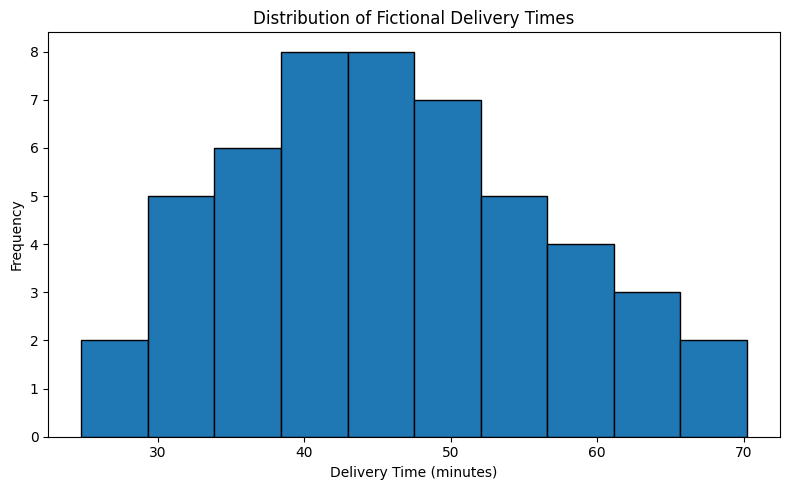

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df["delivery_time_minutes"],bins=10,edgecolor="black")
plt.title("Distribution of Fictional Delivery Times")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Normal Distribution

A Normal Distribution is determined by its mean $\mu$ and standard deviation $\sigma$:

$$X\sim N(\mu,\sigma^2)$$

Its density is

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

You do not need to memorize this formula. The important ideas are symmetry around $\mu$, concentration near the mean, and spread controlled by $\sigma$.

## 7. Visualizing a Normal Distribution

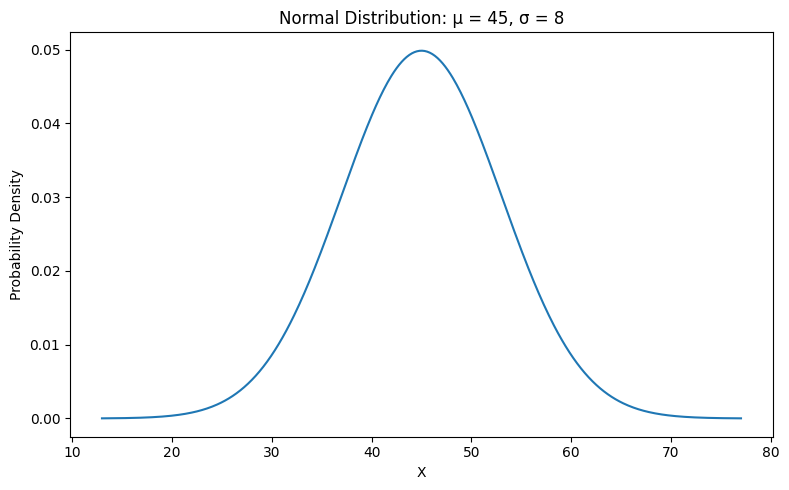

In [4]:
mu,sigma=45,8
x=np.linspace(mu-4*sigma,mu+4*sigma,500)
plt.figure(figsize=(8,5))
plt.plot(x,norm.pdf(x,loc=mu,scale=sigma))
plt.title("Normal Distribution: μ = 45, σ = 8")
plt.xlabel("X")
plt.ylabel("Probability Density")
plt.tight_layout()
plt.show()

## 8. The 68–95–99.7 Rule

For a Normal Distribution, approximately 68% of values lie within $\mu\pm\sigma$, 95% within $\mu\pm2\sigma$, and 99.7% within $\mu\pm3\sigma$.

In [5]:
for z in [1,2,3]:
    prob=norm.cdf(z)-norm.cdf(-z)
    print(f"Within ±{z}σ: {prob:.4%}")

Within ±1σ: 68.2689%
Within ±2σ: 95.4500%
Within ±3σ: 99.7300%


## 9. Cumulative Distribution Function (CDF)

The CDF is

$$F(x)=P(X\le x)$$

For $X\sim N(45,8^2)$, calculate $P(X\le50)$:

In [6]:
p_le_50=norm.cdf(50,loc=mu,scale=sigma)
print(f"P(X <= 50) = {p_le_50:.4f}")

P(X <= 50) = 0.7340


## 10. Probability Between Two Values

$$P(40\le X\le50)=P(X\le50)-P(X\le40)$$

In [7]:
p_between=norm.cdf(50,loc=mu,scale=sigma)-norm.cdf(40,loc=mu,scale=sigma)
print(f"P(40 <= X <= 50) = {p_between:.4f}")

P(40 <= X <= 50) = 0.4680


## 11. Upper-Tail Probability

For $P(X>60)$, use $1-P(X\le60)$ or SciPy's survival function `norm.sf()`.

In [8]:
p_over_60=norm.sf(60,loc=mu,scale=sigma)
print(f"P(X > 60) = {p_over_60:.4f}")

P(X > 60) = 0.0304


## 12. Probability as Area

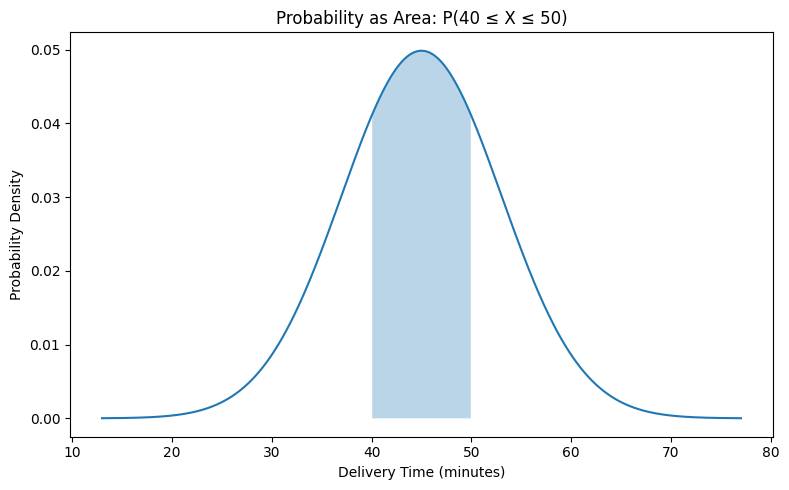

In [9]:
x=np.linspace(mu-4*sigma,mu+4*sigma,500)
density=norm.pdf(x,loc=mu,scale=sigma)
plt.figure(figsize=(8,5))
plt.plot(x,density)
mask=(x>=40)&(x<=50)
plt.fill_between(x[mask],density[mask],alpha=0.3)
plt.title("Probability as Area: P(40 ≤ X ≤ 50)")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.tight_layout()
plt.show()

## 13. Standard Normal Distribution and Z-score

The Standard Normal Distribution has $\mu=0$ and $\sigma=1$:

$$Z\sim N(0,1)$$

An observation can be standardized using

$$Z=\frac{X-\mu}{\sigma}$$

A Z-score tells us how many standard deviations an observation is above or below the mean.

In [10]:
x_value=61
z=(x_value-mu)/sigma
print(f"Z = {z:.2f}")

Z = 2.00


Interpretation:

- Z = 0: at the mean
- Z = 1: one standard deviation above
- Z = -1: one standard deviation below
- Z = 2: two standard deviations above

## 14. Standardizing the Dataset

In [11]:
sample_mean=df["delivery_time_minutes"].mean()
sample_std=df["delivery_time_minutes"].std(ddof=1)

df_z=df.copy()
df_z["z_score"]=(df_z["delivery_time_minutes"]-sample_mean)/sample_std

print(f"Sample mean: {sample_mean:.3f}")
print(f"Sample SD: {sample_std:.3f}")
df_z.head(10)

Sample mean: 45.898
Sample SD: 10.871


,delivery_id,delivery_time_minutes,z_score
0,Delivery_01,24.8,-1.940787
1,Delivery_02,28.1,-1.637223
2,Delivery_03,29.4,-1.517637
3,Delivery_04,30.2,-1.444046
4,Delivery_05,31.7,-1.306062
5,Delivery_06,32.5,-1.232471
6,Delivery_07,33.1,-1.177277
7,Delivery_08,34.6,-1.039293
8,Delivery_09,35.0,-1.002498
9,Delivery_10,35.8,-0.928907


## 15. Observed Data vs Theoretical Model

The CSV contains **synthetic observed values**.

A distribution such as

$$N(45,8^2)$$

is a **theoretical probability model**.

Observed data do not have to follow a Normal Distribution perfectly. Later chapters will use probability models as a foundation for statistical inference.

## 16. Simulation from a Normal Distribution

In [12]:
rng=np.random.default_rng(seed=42)
simulated=rng.normal(loc=45,scale=8,size=10_000)

print(f"Simulated mean: {simulated.mean():.3f}")
print(f"Simulated SD: {simulated.std(ddof=0):.3f}")

Simulated mean: 44.918
Simulated SD: 8.050


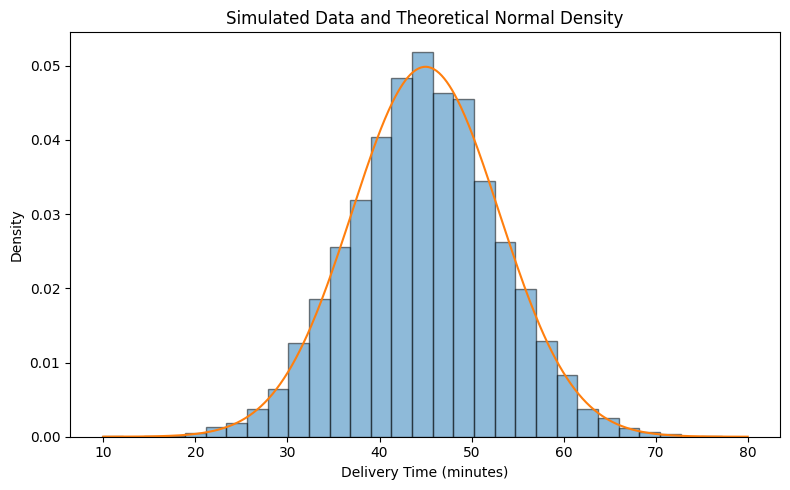

In [13]:
plt.figure(figsize=(8,5))
plt.hist(simulated,bins=30,density=True,edgecolor="black",alpha=0.5)
x=np.linspace(10,80,500)
plt.plot(x,norm.pdf(x,loc=45,scale=8))
plt.title("Simulated Data and Theoretical Normal Density")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## 17. PDF vs CDF

**PDF — `norm.pdf(x)`** describes density and the shape of the distribution. Its value at one point is not itself a probability.

**CDF — `norm.cdf(x)`** gives

$$P(X\le x)$$

A useful rule:

> **PDF describes the shape; CDF accumulates probability.**

## Exercises

1. Classify customer count, waiting time, temperature, defect count, and body weight as discrete or continuous.
2. For $X\sim N(100,15^2)$, calculate $P(X\le100)$, $P(X\le115)$, $P(85\le X\le115)$, and $P(X>130)$.
3. For $\mu=70,\sigma=10$, calculate Z-scores for $X=70,80,50$.
4. Plot normal distributions with $\sigma=5,10,20$ and the same mean.
5. Simulate 100,000 observations from $N(50,10^2)$ and compare proportions within 1, 2, and 3 standard deviations with the 68–95–99.7 rule.
6. Explain why $P(X=50)=0$ does not mean observing a value near 50 is impossible.

## Summary

For continuous variables, **probability is represented by area under a density curve**.

You learned about PDF, CDF, the Normal Distribution, the 68–95–99.7 rule, interval and tail probabilities, the Standard Normal Distribution, Z-scores, and simulation.

This completes **Part 2 — Probability**.

Next:

# Part 3 — Statistical Inference
## 10 Sampling

We will move from probability models toward using samples to learn about populations.